In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('diabetes.csv')

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='Outcome'>

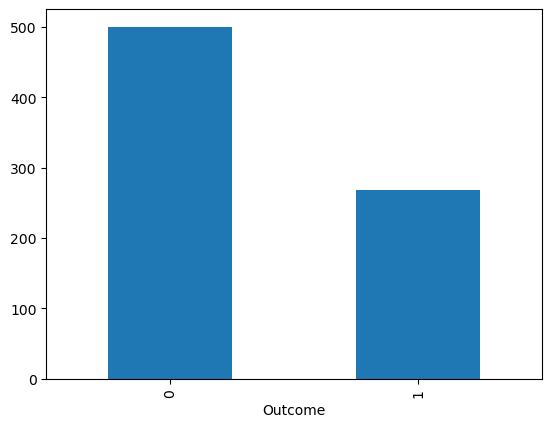

In [10]:
df['Outcome'].value_counts().plot(kind='bar')

In [11]:
df.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


In [14]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


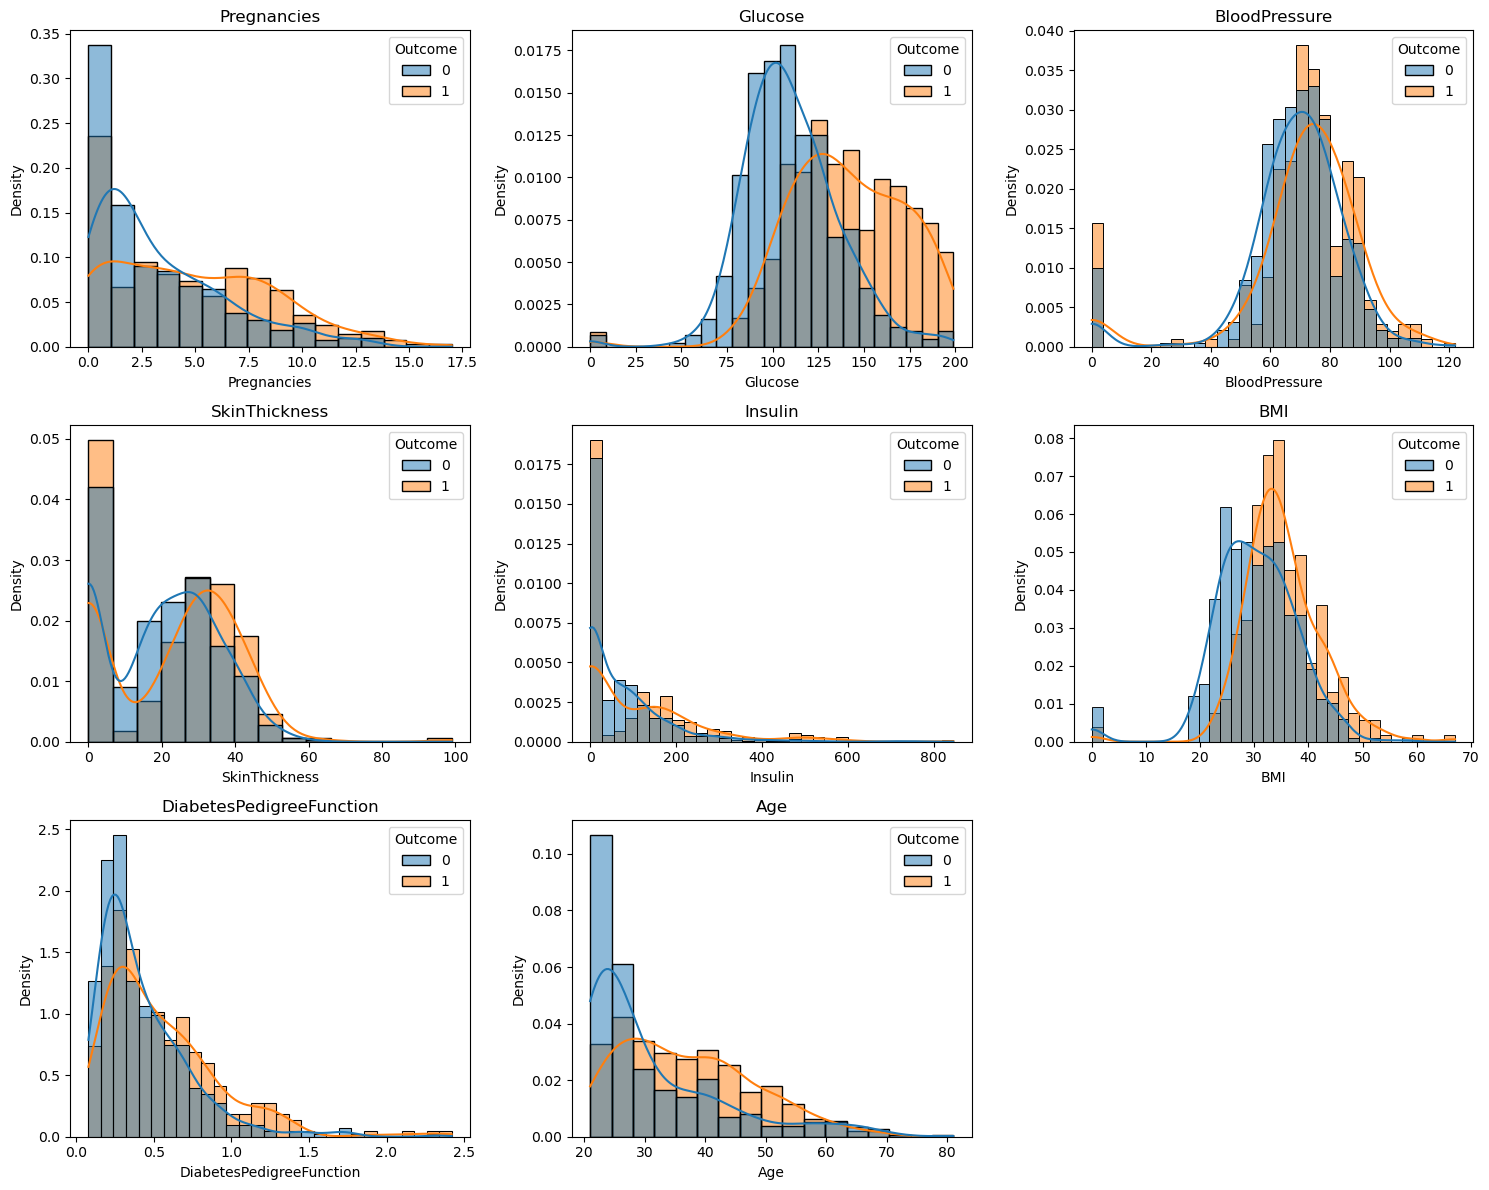

In [ ]:
num_cols = df.select_dtypes(include='number').columns.drop('Outcome')

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(
        data=df,
        x=col,
        hue='Outcome',
        kde=True,
        stat='density',
        common_norm=False,
        alpha=0.5,
        ax=axes[i]
    )
    axes[i].set_title(col)

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

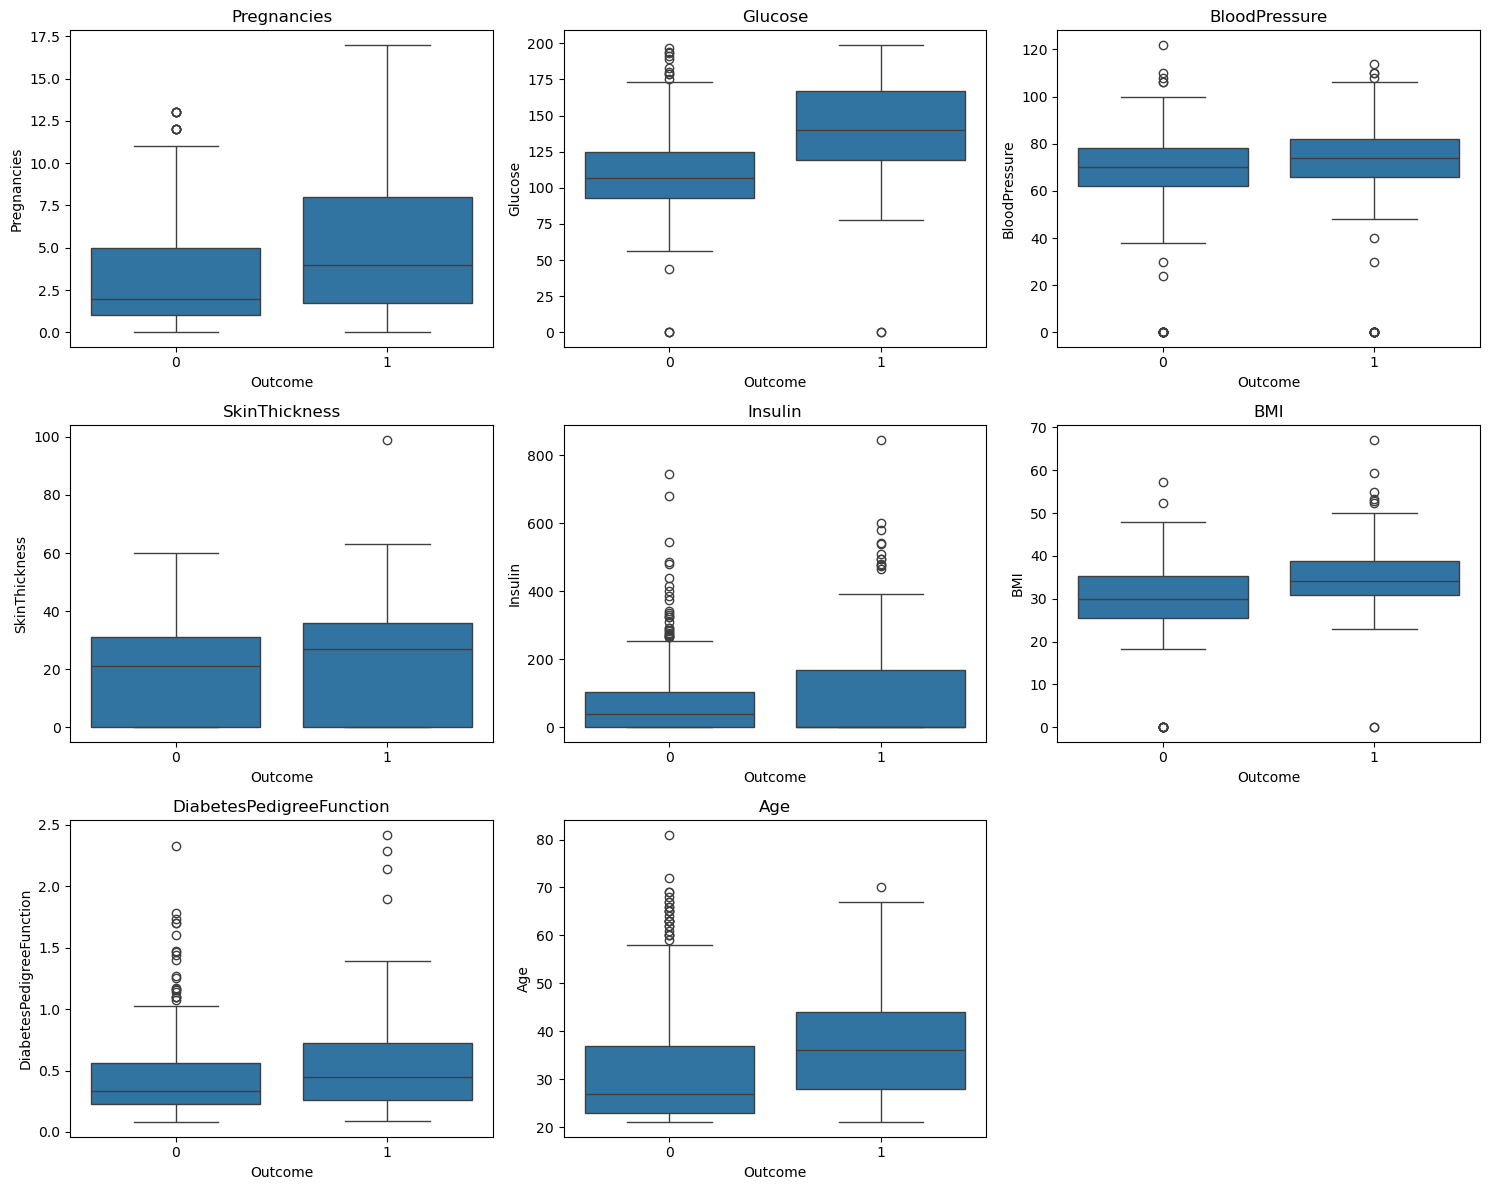

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        data=df,
        x='Outcome',
        y=col,
        ax=axes[i]
    )
    axes[i].set_title(col)

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [20]:
from scipy.stats import shapiro

num_cols = df.select_dtypes(include='number').columns.drop('Outcome')

resultados = []

for col in num_cols:
    for outcome in sorted(df['Outcome'].unique()):
        dados = df.loc[df['Outcome'] == outcome, col].dropna()

        stat, pvalue = shapiro(dados)

        resultados.append({
            'Variavel': col,
            'Outcome': outcome,
            'N': len(dados),
            'Estatística': round(stat, 4),
            'p-valor': pvalue,
            'Normal? (α=0.05)': 'Sim' if pvalue > 0.05 else 'Não'
        })

resultado_df = pd.DataFrame(resultados)

tabela = resultado_df.pivot(
    index='Variavel',
    columns='Outcome',
    values=['Estatística', 'p-valor', 'Normal? (α=0.05)']
)

tabela

Estatística         p-valor            \
Outcome                            0       1       0         1   
Variavel                                                         
Age                           0.8012  0.9546     0.0       0.0   
BMI                           0.9431  0.9283     0.0       0.0   
BloodPressure                 0.8316  0.7844     0.0       0.0   
DiabetesPedigreeFunction      0.8287  0.8575     0.0       0.0   
Glucose                       0.9679  0.9588     0.0  0.000001   
Insulin                       0.7162  0.7462     0.0       0.0   
Pregnancies                   0.8793  0.9432     0.0       0.0   
SkinThickness                 0.9193  0.8691     0.0       0.0   

                         Normal? (α=0.05)       
Outcome                                 0    1  
Variavel                                        
Age                                   Não  Não  
BMI                                   Não  Não  
BloodPressure                         Não  Não  
DiabetesPedigreeFunction              Não  Não  
Glucose                               Não  Não  
Insulin                               Não  Não  
Pregnancies                           Não  Não  
SkinThickness                         Não  Não